In [1]:
import numpy as np
from sklearn.decomposition import PCA

In [2]:
filename = 'compTempTagR.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(','))
for x in dense_coding_table[:10]:
    print(x)

['tag', 'eng', 'cym', 'deu', 'pol']
['sim-point', 'at', 'yn', 'zu', '--']
['sim-cont', 'in', 'other', 'zu', '--']
['sim-point', 'at', 'other', '--', 'other']
['sim-point', 'at', 'other', 'in', '--']
['sim-day', 'on', 'ar', 'an', 'w']
['sim-day', 'on', 'ar', 'an', 'w']
['sim-day', 'on', 'ar', 'an', 'w']
['sim-day', 'on', 'ar', 'an', 'w']
['sim-point', 'at', 'yn', 'an', 'przy']


In [3]:
def get_sparse_coding(dense_coding_table, no_response):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict
            

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng': {'at': 0, 'in': 1, 'on': 2}, 'cym': {'yn': 0, 'other': 1, 'ar': 2, 'zero': 3, 'mewn': 4}, 'deu': {'zu': 0, 'in': 1, 'an': 2, 'zero': 3, 'nach': 4, 'um': 5, 'other': 6}, 'pol': {'other': 0, 'w': 1, 'przy': 2, 'zero': 3, 'podczas': 4, 'zaś': 5, 'na': 6}}
>>> header ['eng_at', 'eng_in', 'eng_on', 'cym_yn', 'cym_other', 'cym_ar', 'cym_zero', 'cym_mewn', 'deu_zu', 'deu_in', 'deu_an', 'deu_zero', 'deu_nach', 'deu_um', 'deu_other', 'pol_other', 'pol_w', 'pol_przy', 'pol_zero', 'pol_podczas', 'pol_zaś', 'pol_na']
[1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [4]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[2.34257903e-01 1.68835336e-01 1.20791595e-01 7.88497034e-02
 6.98199375e-02 4.90683899e-02 4.18756660e-02 3.95382286e-02
 3.69503831e-02 3.07423199e-02 2.38990873e-02 2.09122871e-02
 1.77501947e-02 1.57667396e-02 1.32195356e-02 9.57705765e-03
 9.29545549e-03 7.46771448e-03 5.69736326e-03 3.36995799e-03
 2.31514426e-03 1.23838390e-33]


-0.24128098170309367 -0.24725289312639076 sim-point
-0.39464832575056247 0.6512471142869163 sim-cont
0.11636042763153118 0.23597756223923327 sim-point
-0.27392766745277364 -0.1349636475039549 sim-point
1.313305435534987 -0.34819724081805015 sim-day
1.313305435534986 -0.34819724081805054 sim-day
1.3133054355349867 -0.3481972408180501 sim-day
1.3133054355349862 -0.3481972408180503 sim-day
0.1785153581371252 0.11895789108239863 sim-point
0.17851535813712602 0.1189578910823998 sim-point
0.3583897280048212 -0.6280976874343993 sim-point
-0.29603998487850847 0.9175594667637308 sim-part
0.1718633708686033 1.0278285543872505 sim-part
-0.2960399848785085 0.9175594667637305 sim-part
-1.074570284327474 -0.5307394110530367 sim-cont
-1.1972377601014323 0.20915434890892073 sim-seas
0.10895622209860231 0.15533094313906506 sim-point
-0.1610590336380217 -0.9478145407982447 sim-point
1.3133054355349867 -0.3481972408180502 sim-day
0.5066715766371934 0.41661898811686576 sim-hour
-0.42003057728662707 0.9333

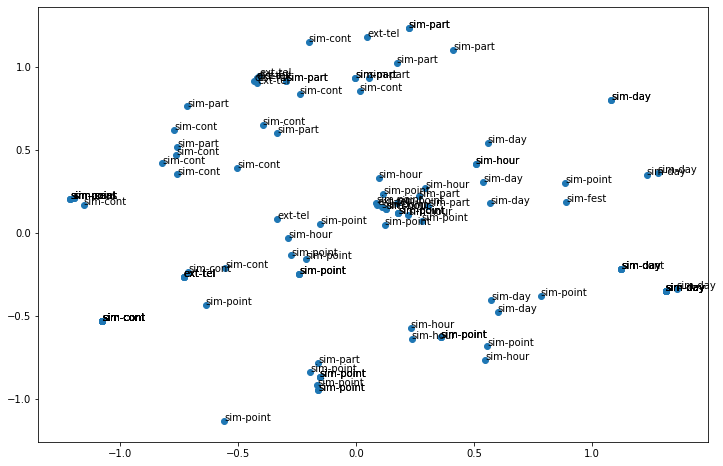

0 eng_at


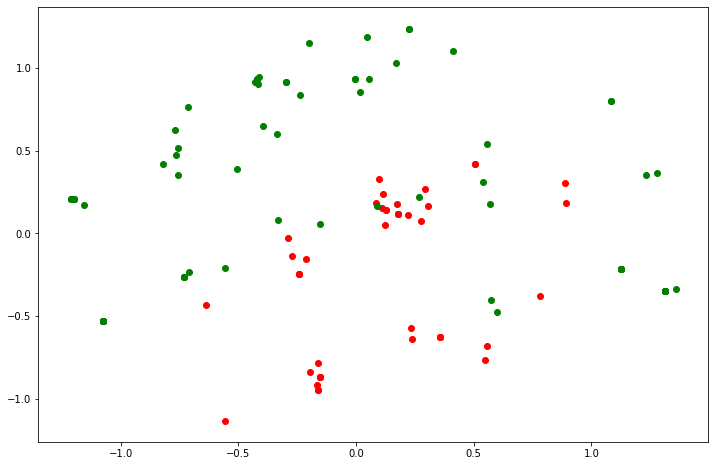

1 eng_in


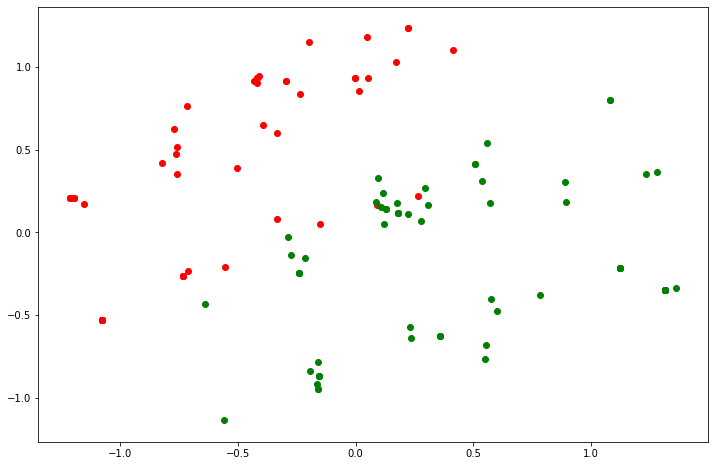

2 eng_on


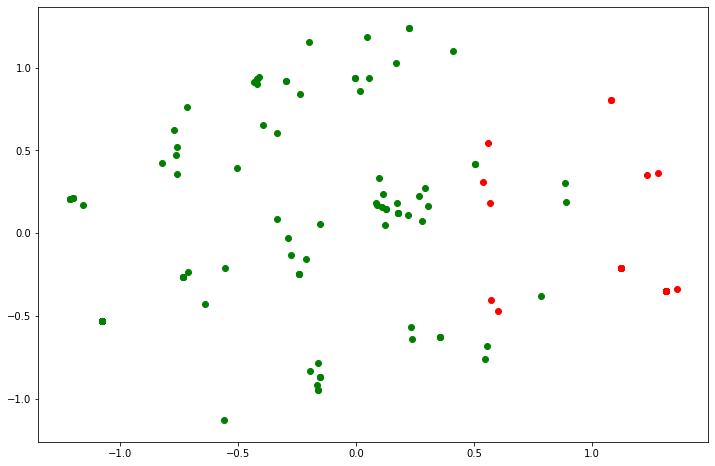

3 cym_yn


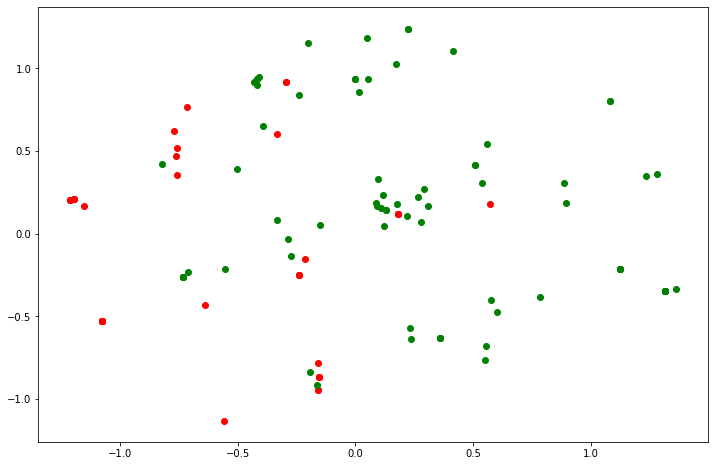

4 cym_other


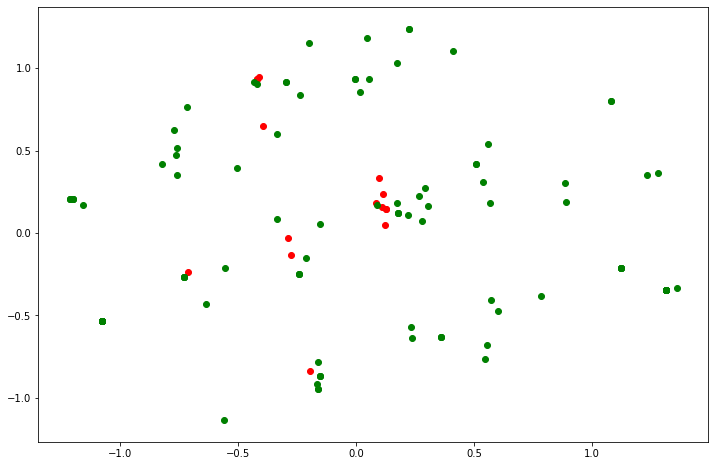

5 cym_ar


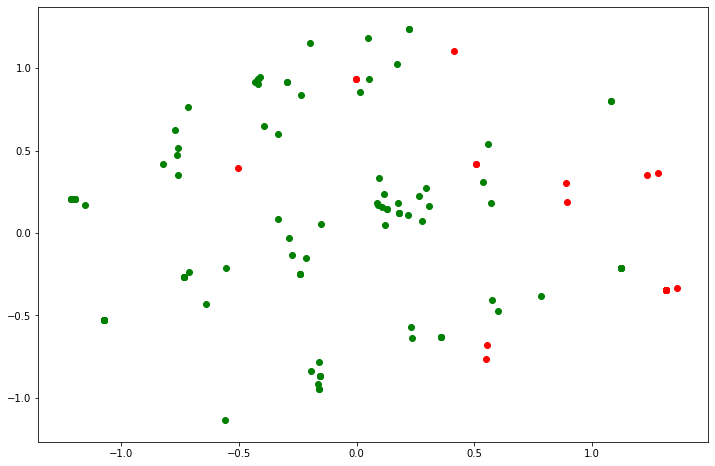

6 cym_zero


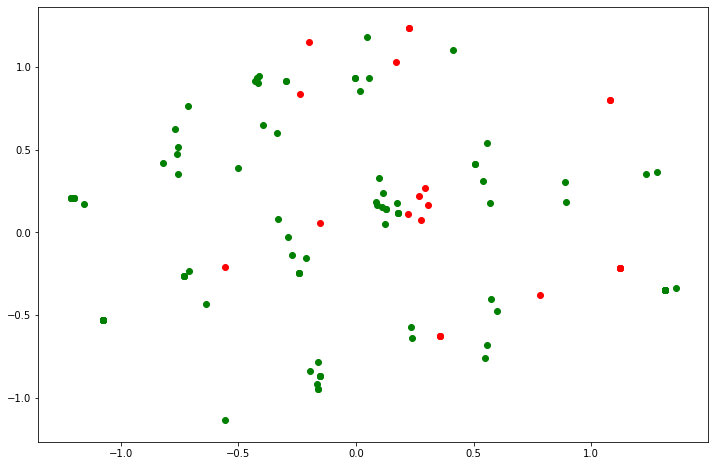

7 cym_mewn


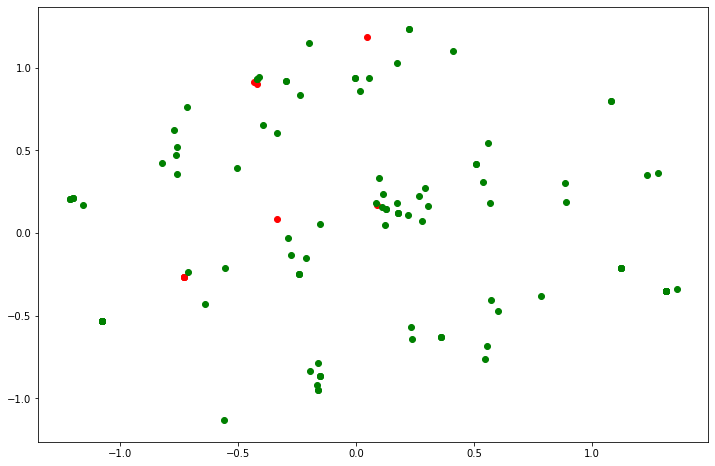

8 deu_zu


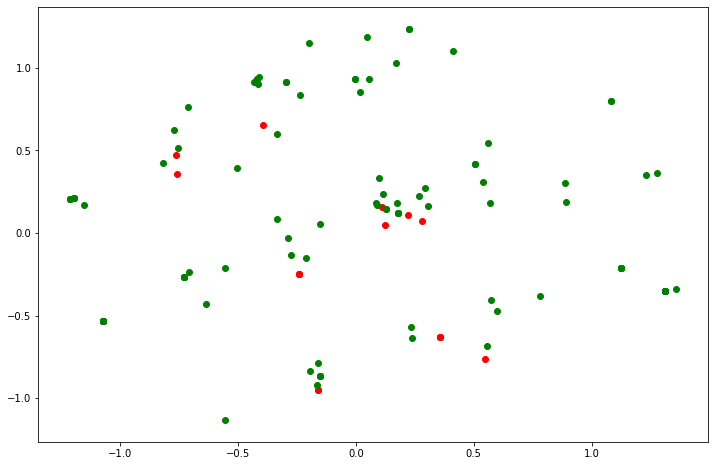

9 deu_in


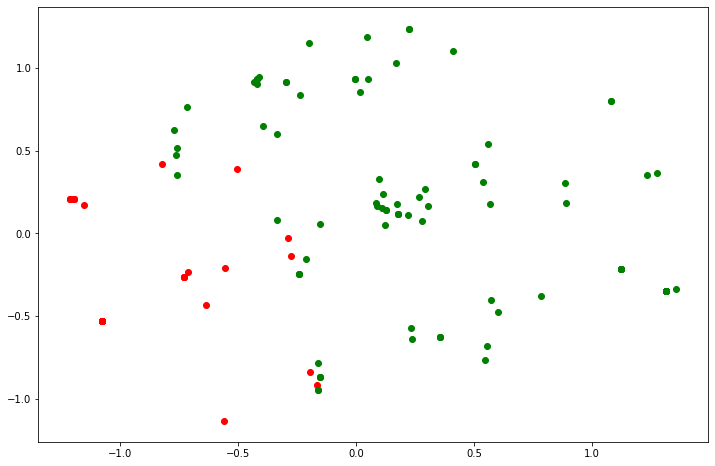

10 deu_an


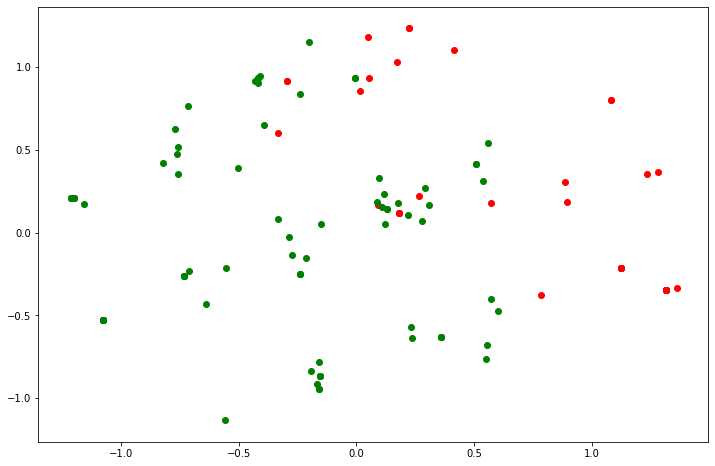

11 deu_zero


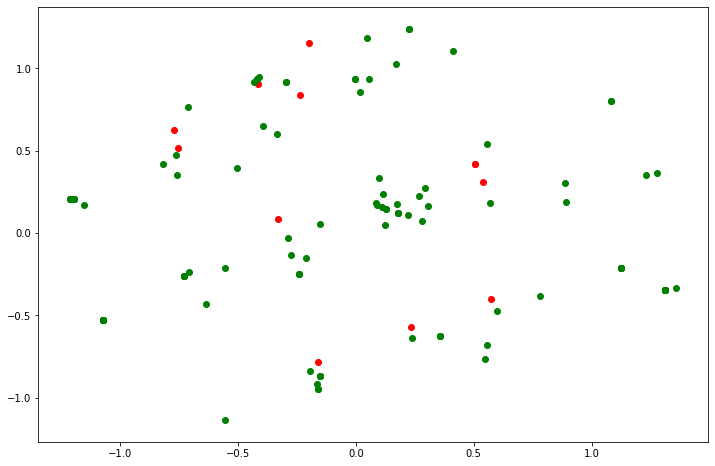

12 deu_nach


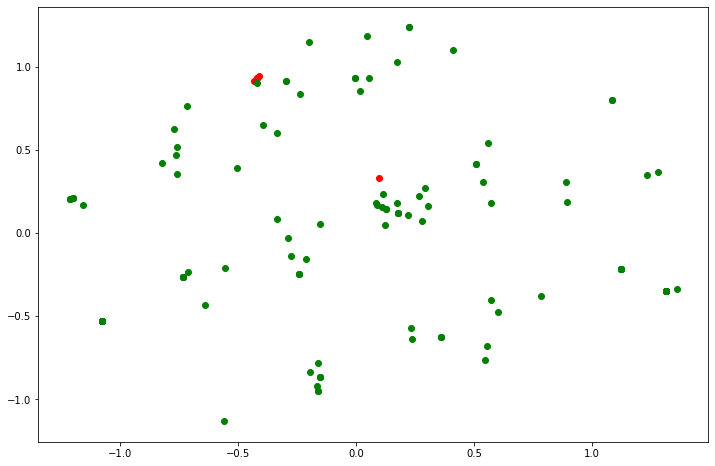

13 deu_um


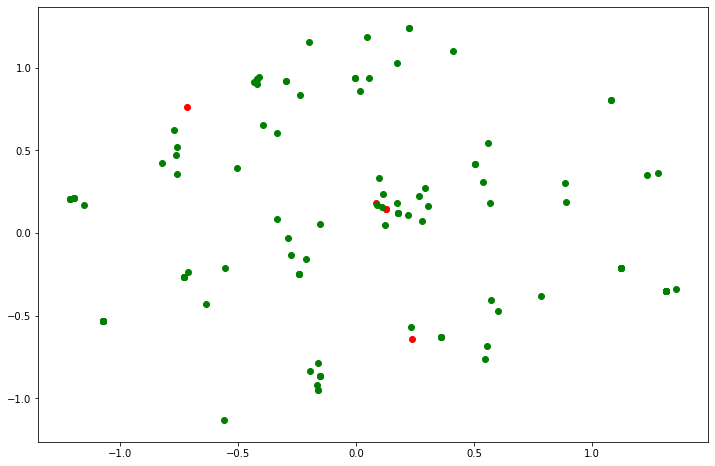

14 deu_other


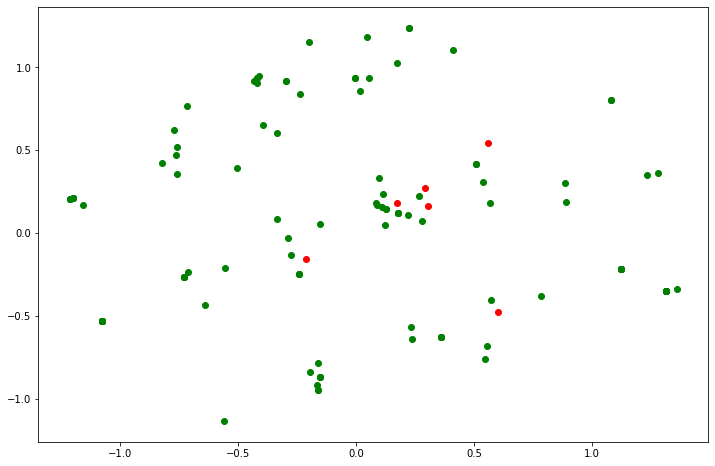

15 pol_other


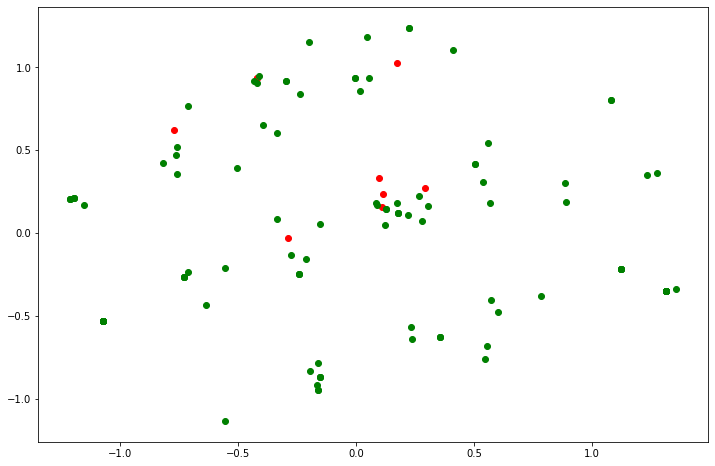

16 pol_w


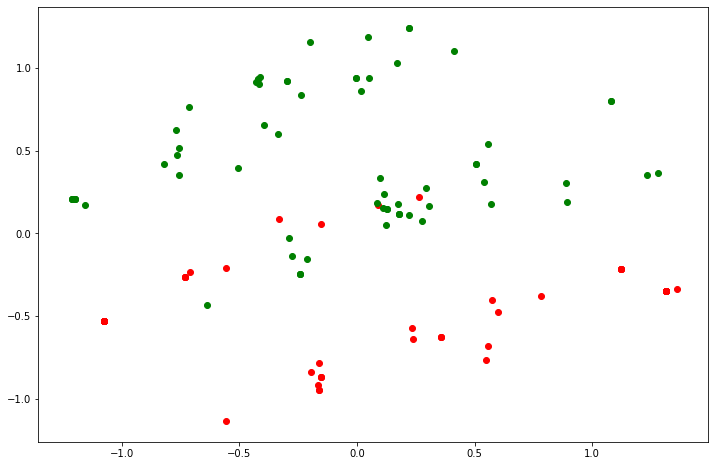

17 pol_przy


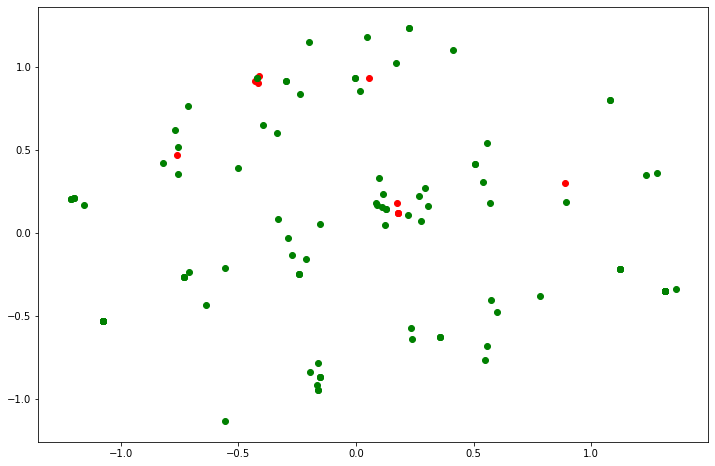

18 pol_zero


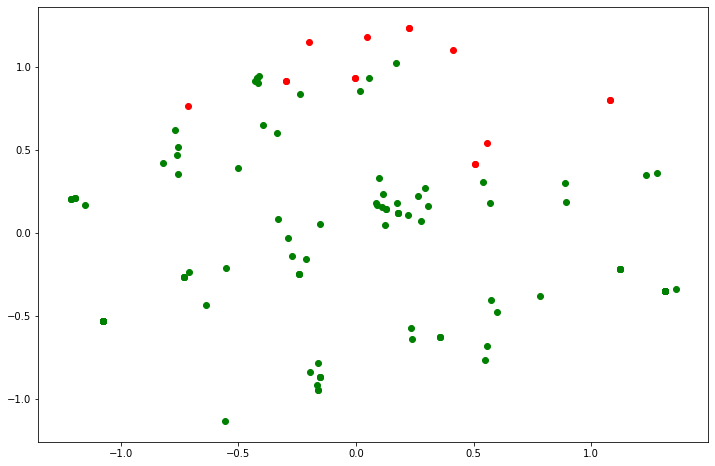

19 pol_podczas


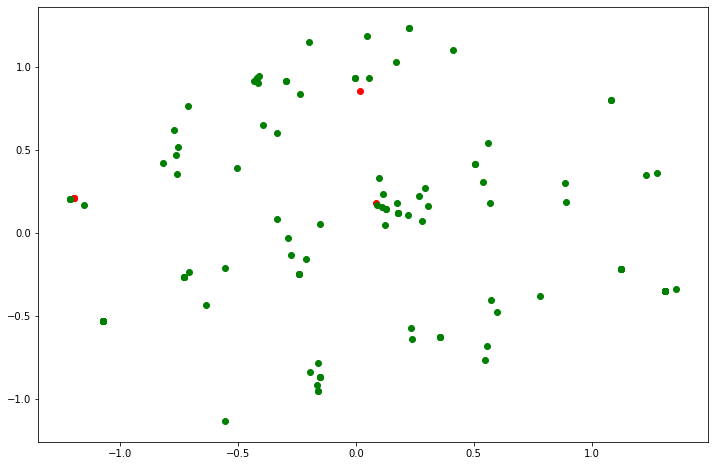

20 pol_zaś


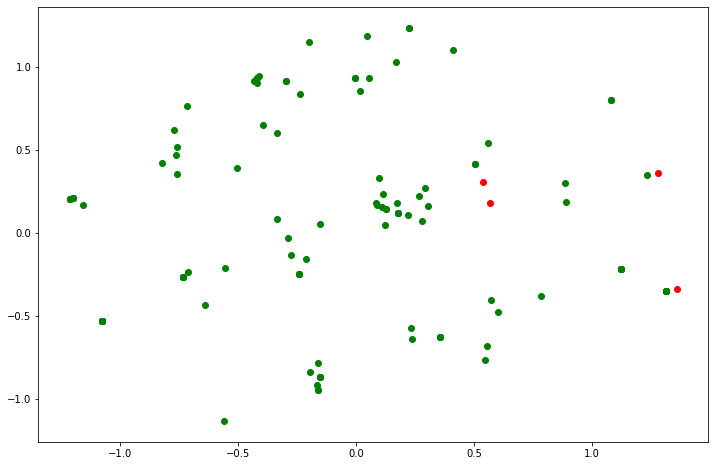

21 pol_na


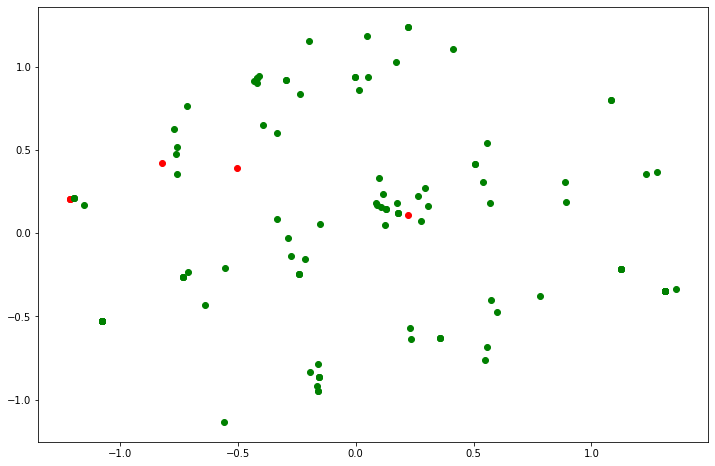

In [6]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (12,8)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    plt.show()
    plt.close()